## Data Analysis of Nvidia (NVDA) Stock

### 1. Prepare Your Data

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as web
import datetime as dt

#### Load the Stock Price Dataset into a Pandas DataFrame

In [53]:
nvda_df=pd.read_csv("/content/NVDA.csv")
display(nvda_df.head())

,Date,Close,High,Low,Open,Volume
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


#### Ensure Columns are Correctly Typed

In [54]:
nvda_df['Date'] = pd.to_datetime(nvda_df['Date'])
nvda_df = nvda_df.set_index('Date')

#### Check for and Handle Missing Values

In [55]:
print('DataFrame Info:')
nvda_df.info()

print('\nMissing values in each column:')
display(nvda_df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Open    3774 non-null   float64
 4   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB

Missing values in each column:


,0
Close,0
High,0
Low,0
Open,0
Volume,0


As confirmed above, there are no missing values in our dataset, so no further handling is required at this stage.

### 2. Compute Technical Indicators with TA-Lib

In [ ]:
!pip install TA-Lib

#### Calculate Moving Averages (SMA, EMA), Relative Strength Index (RSI), and MACD

In [56]:
!pip install TA-Lib
import talib

nvda_df['SMA_10'] = talib.SMA(nvda_df['Close'], timeperiod=10)
nvda_df['SMA_30'] = talib.SMA(nvda_df['Close'], timeperiod=30)

nvda_df['EMA_10'] = talib.EMA(nvda_df['Close'], timeperiod=10)
nvda_df['EMA_30'] = talib.EMA(nvda_df['Close'], timeperiod=30)

nvda_df['RSI'] = talib.RSI(nvda_df['Close'], timeperiod=14)

macd, macdsignal, macdhist = talib.MACD(nvda_df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
nvda_df['MACD'] = macd
nvda_df['MACD_Signal'] = macdsignal
nvda_df['MACD_Hist'] = macdhist

display(nvda_df.tail())

,Close,High,Low,Open,Volume,SMA_10,SMA_30,EMA_10,EMA_30,RSI,MACD,MACD_Signal,MACD_Hist
Date,,,,,,,,,,,,,
2023-12-22,48.805527,49.358247,48.442706,49.170342,252507000,48.498082,48.165746,48.506691,47.596592,55.352119,0.634352,0.564438,0.069914
2023-12-26,49.254299,49.575137,48.935459,48.943454,244200000,48.763148,48.197338,48.642620,47.703541,57.245971,0.655689,0.582688,0.073001
2023-12-27,49.392231,49.655100,49.060397,49.486186,233648000,48.939060,48.224034,48.778913,47.812489,57.837928,0.675937,0.601338,0.074599
2023-12-28,49.497185,49.859003,49.387239,49.618126,246587000,49.082388,48.219715,48.909507,47.921179,58.310919,0.692470,0.619564,0.072906
2023-12-29,49.497185,49.971949,48.726571,49.788039,389293000,49.199530,48.240981,49.016358,48.022857,58.310919,0.697532,0.635158,0.062374


### Insights on Calculated Technical Indicators:

These technical indicators are crucial tools for understanding Nvidia's (NVDA) stock price movements:

1. **Simple Moving Averages (SMA)**: Smooths NVDA's price action to identify long-term trends.
2. **Exponential Moving Averages (EMA)**: More responsive to NVDA's recent volatile price changes.
3. **RSI**: Identifies if NVDA is overbought (>70) or oversold (<30).
4. **MACD**: Shows momentum shifts and potential trend reversals for NVDA.

### 3. Apply PyNance for Financial Metrics

In [ ]:
!pip install pynance

#### Understanding PyNance and Calculating Additional Metrics

While `TA-Lib` is excellent for calculating a wide array of technical indicators (like SMA, RSI, MACD), `PyNance` is a broader financial analysis framework. It focuses on object-oriented representations of financial instruments (like stocks), portfolios, and provides tools for tasks such as valuation, risk management, and constructing financial models rather than just adding indicator columns to a DataFrame.

For calculating additional *metrics* that extend beyond typical technical indicators but are often used in financial analysis, we can leverage pandas. Below, we will calculate **Daily Returns** and **Historical Volatility** for the Google stock.

In [57]:
nvda_df['Daily_Return'] = nvda_df['Close'].pct_change() * 100
nvda_df['Volatility_20_Day'] = nvda_df['Daily_Return'].rolling(window=20).std()
display(nvda_df.tail())

,Close,High,Low,Open,Volume,SMA_10,SMA_30,EMA_10,EMA_30,RSI,MACD,MACD_Signal,MACD_Hist,Daily_Return,Volatility_20_Day
Date,,,,,,,,,,,,,,,
2023-12-22,48.805527,49.358247,48.442706,49.170342,252507000,48.498082,48.165746,48.506691,47.596592,55.352119,0.634352,0.564438,0.069914,-0.326597,1.882272
2023-12-26,49.254299,49.575137,48.935459,48.943454,244200000,48.763148,48.197338,48.642620,47.703541,57.245971,0.655689,0.582688,0.073001,0.919511,1.880987
2023-12-27,49.392231,49.655100,49.060397,49.486186,233648000,48.939060,48.224034,48.778913,47.812489,57.837928,0.675937,0.601338,0.074599,0.280040,1.866454
2023-12-28,49.497185,49.859003,49.387239,49.618126,246587000,49.082388,48.219715,48.909507,47.921179,58.310919,0.692470,0.619564,0.072906,0.212490,1.862992
2023-12-29,49.497185,49.971949,48.726571,49.788039,389293000,49.199530,48.240981,49.016358,48.022857,58.310919,0.697532,0.635158,0.062374,0.000000,1.725006


### Understanding the Financial Metrics: Deeper Insights

1. **Daily Returns (`nvda_df['Daily_Return']`)**: Measures the daily percentage fluctuation in Nvidia's valuation.
2. **Historical Volatility (`nvda_df['Volatility_20_Day']`)**: Captures the intensity of Nvidia's price swings over a rolling 20-day window.

### 4. Visualize the Data

These plots illustrate the relationship between NVDA's price action and its technical indicators.

#### Plot Closing Prices Overlaid with Moving Averages

##### META Close Price with Simple Moving Averages - Standalone

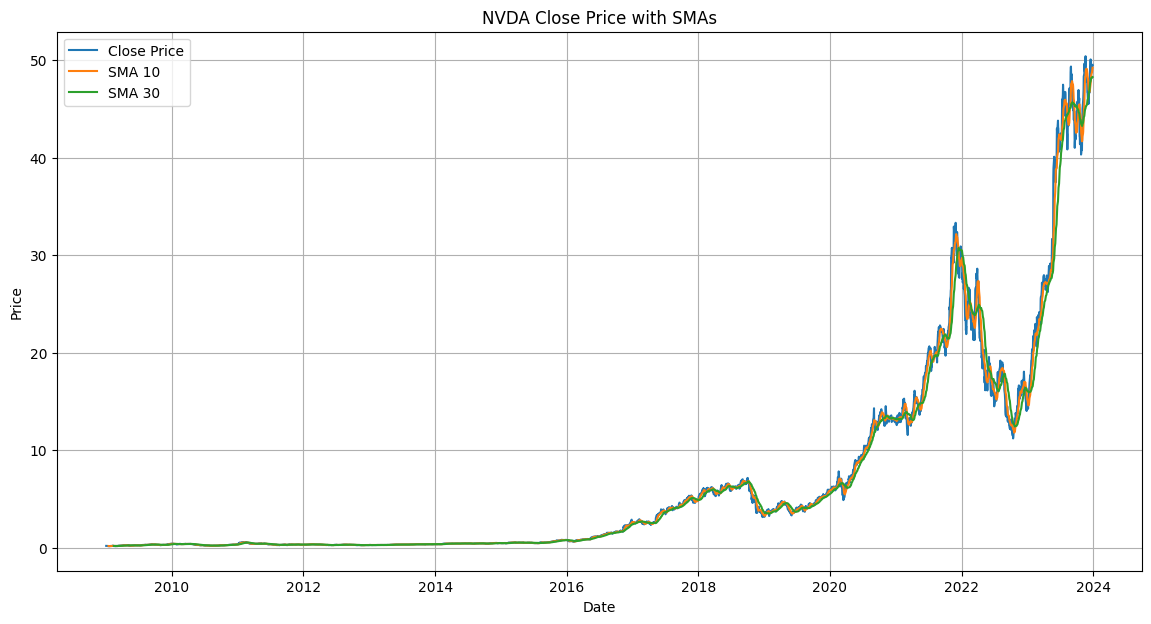

In [58]:
plt.figure(figsize=(14, 7))
plt.plot(nvda_df['Close'], label='Close Price')
plt.plot(nvda_df['SMA_10'], label='SMA 10')
plt.plot(nvda_df['SMA_30'], label='SMA 30')
plt.title('NVDA Close Price with SMAs')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

##### META Close Price with Simple and Exponential Moving Averages - Standalone

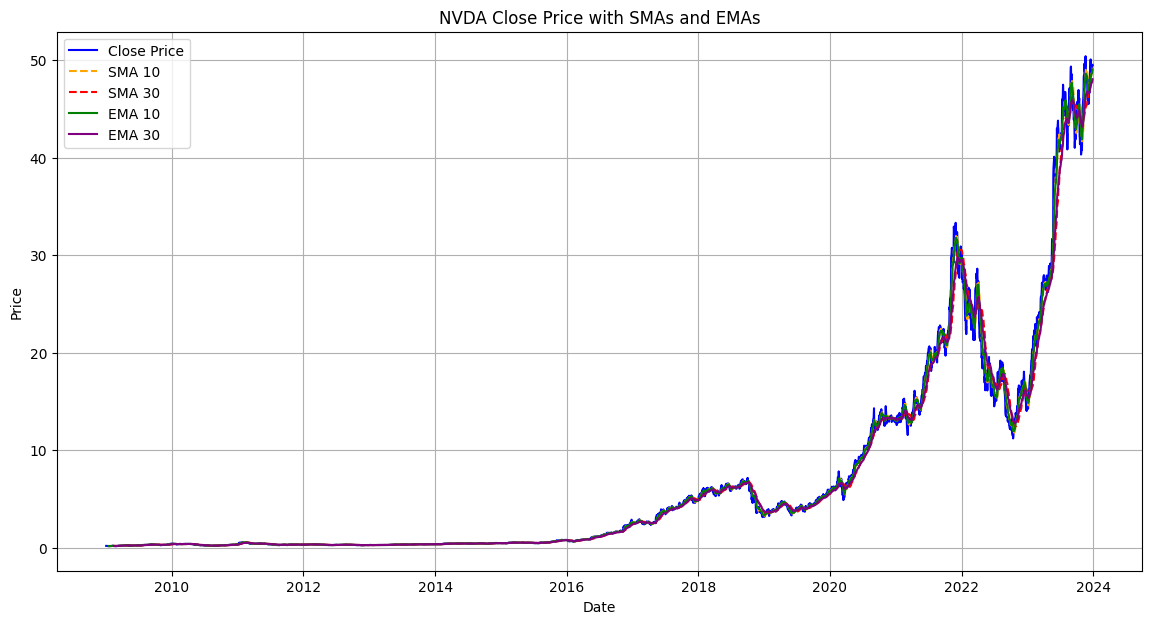

In [59]:
plt.figure(figsize=(14, 7))
plt.plot(nvda_df['Close'], label='Close Price', color='blue')
plt.plot(nvda_df['SMA_10'], label='SMA 10', color='orange', linestyle='--')
plt.plot(nvda_df['SMA_30'], label='SMA 30', color='red', linestyle='--')
plt.plot(nvda_df['EMA_10'], label='EMA 10', color='green')
plt.plot(nvda_df['EMA_30'], label='EMA 30', color='purple')
plt.title('NVDA Close Price with SMAs and EMAs')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

#### Plot RSI and MACD in Separate Panels showing relation to Price Action

##### Combined Plot: META Close Price with Relative Strength Index (RSI)

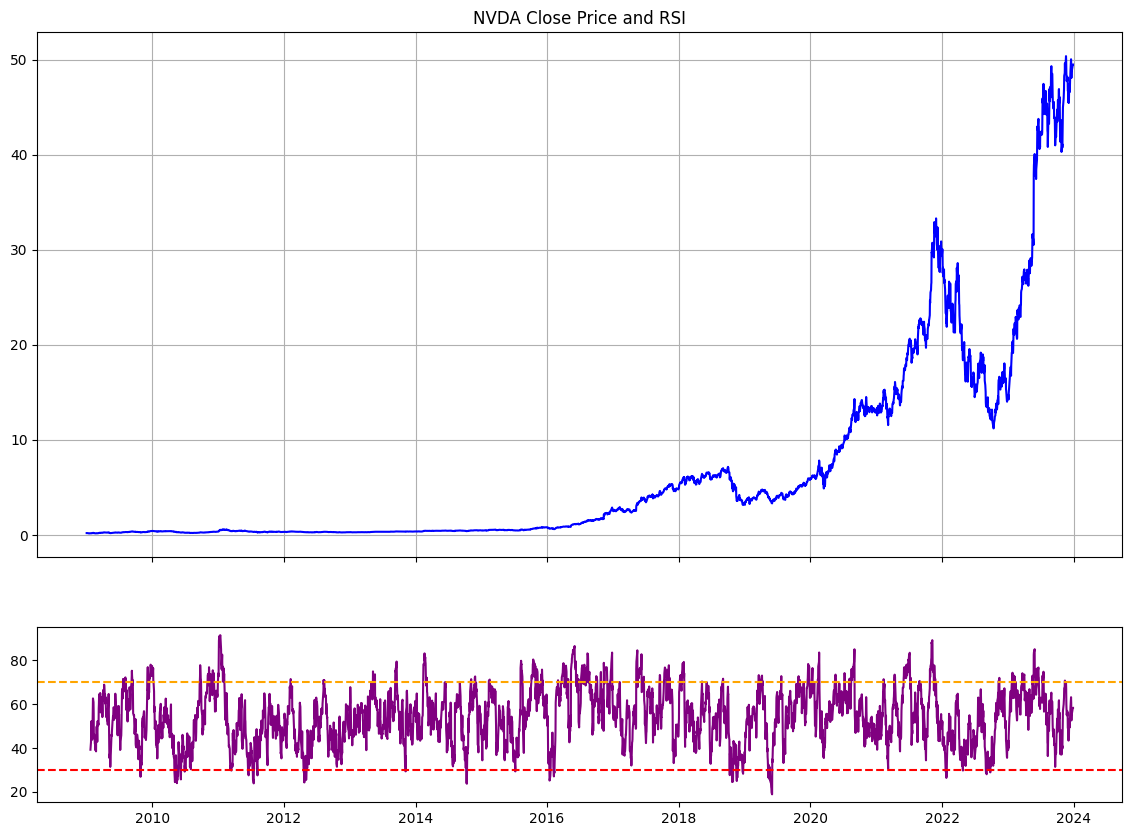

In [60]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(nvda_df['Close'], label='Close Price', color='blue')
ax1.set_title('NVDA Close Price and RSI')
ax1.grid(True)
ax2.plot(nvda_df['RSI'], label='RSI', color='purple')
ax2.axhline(70, linestyle='--', color='orange')
ax2.axhline(30, linestyle='--', color='red')
plt.show()

##### Combined Plot: META Close Price with Moving Average Convergence Divergence (MACD)

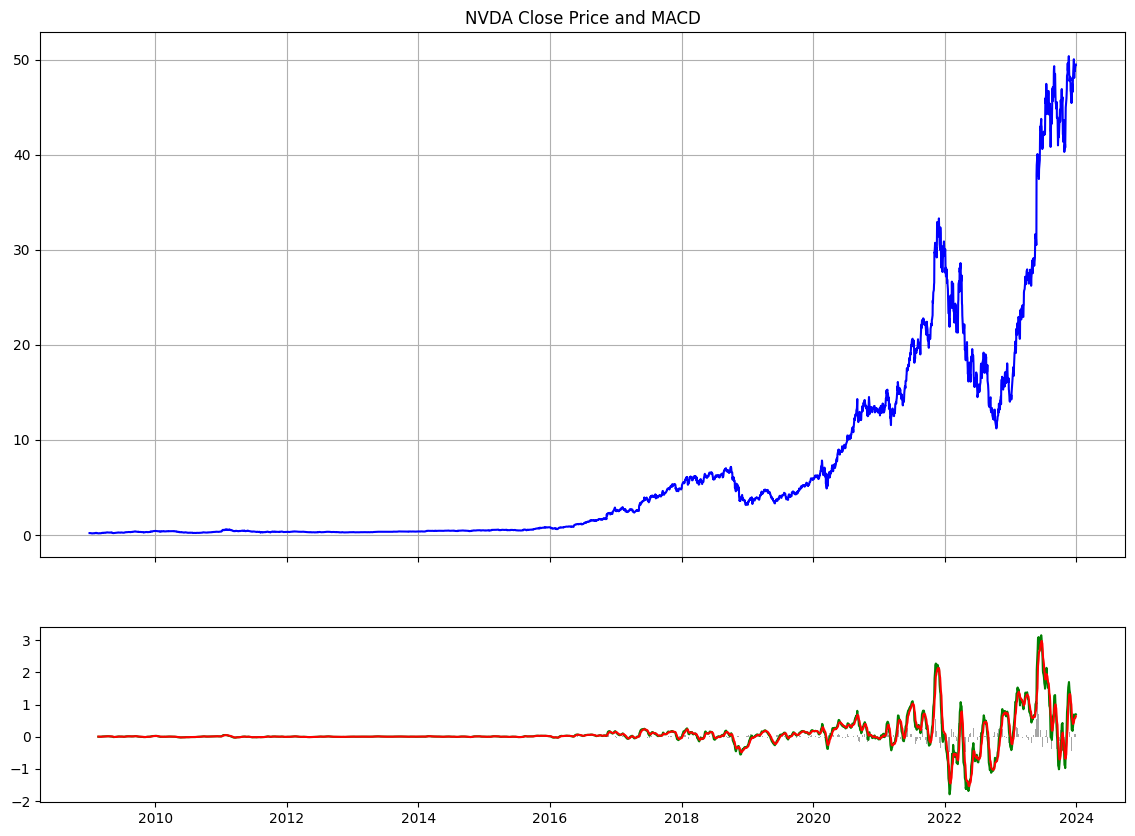

In [61]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(nvda_df['Close'], label='Close Price', color='blue')
ax1.set_title('NVDA Close Price and MACD')
ax1.grid(True)
ax2.plot(nvda_df['MACD'], label='MACD', color='green')
ax2.plot(nvda_df['MACD_Signal'], label='Signal', color='red')
ax2.bar(nvda_df.index, nvda_df['MACD_Hist'], color='gray', alpha=0.7)
plt.show()

##### META: Multi-Panel Visualization (Price, RSI, and MACD)

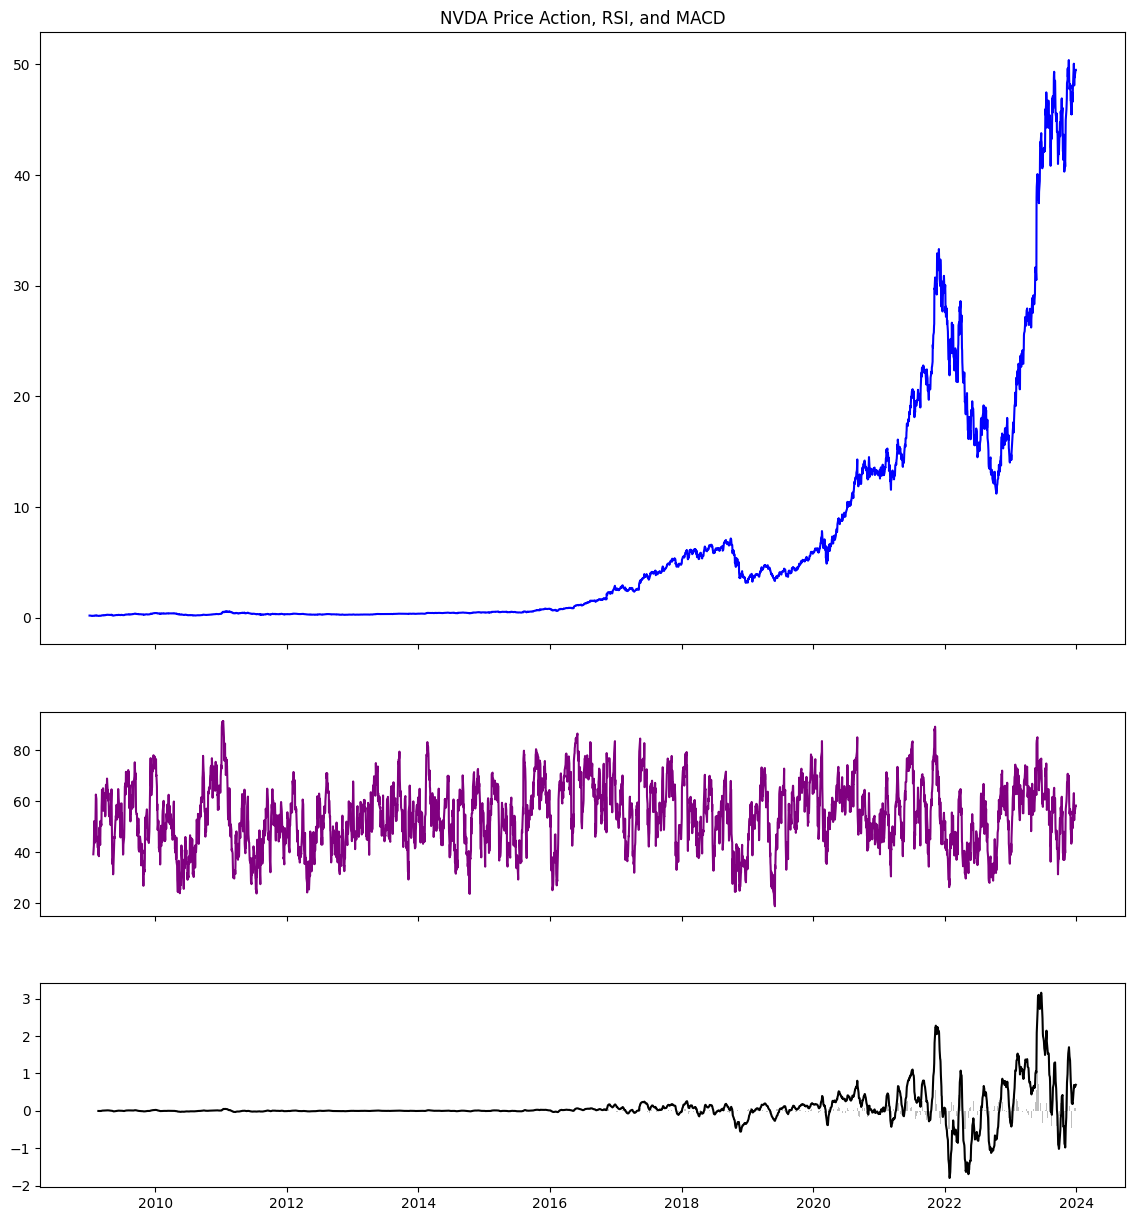

In [62]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})
ax1.plot(nvda_df['Close'], label='Close Price', color='blue')
ax1.set_title('NVDA Price Action, RSI, and MACD')
ax2.plot(nvda_df['RSI'], color='purple')
ax3.plot(nvda_df['MACD'], color='black')
ax3.bar(nvda_df.index, nvda_df['MACD_Hist'], color='gray', alpha=0.5)
plt.show()

#### Plot Daily Returns and Historical Volatility

##### META Daily Returns Plot

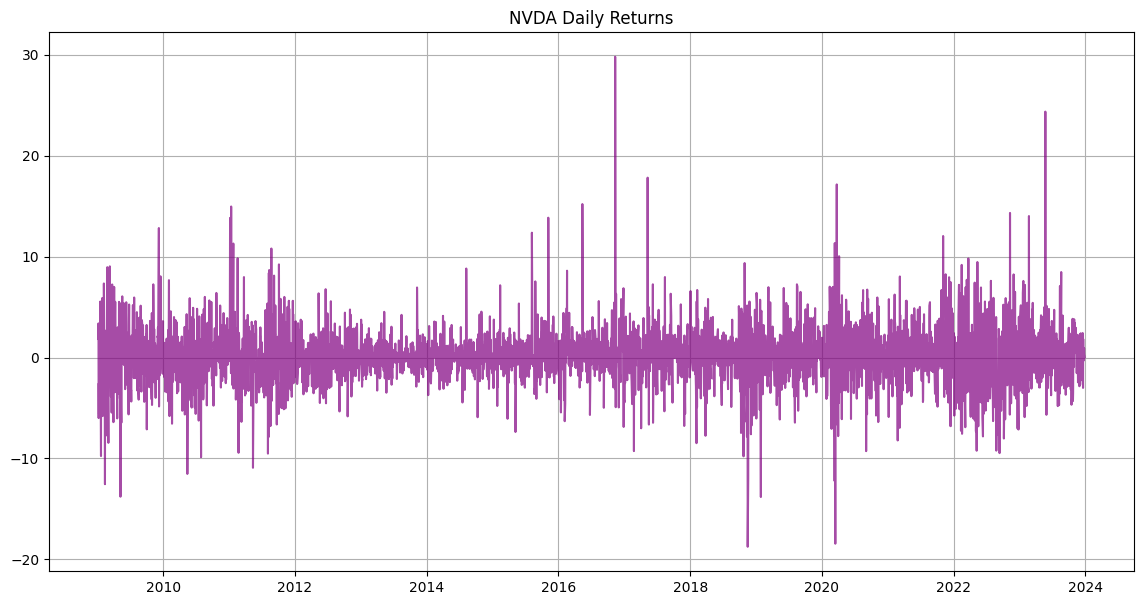

In [63]:
plt.figure(figsize=(14, 7))
plt.plot(nvda_df['Daily_Return'], color='purple', alpha=0.7)
plt.title('NVDA Daily Returns')
plt.grid(True)
plt.show()

##### META 20-Day Historical Volatility Plot

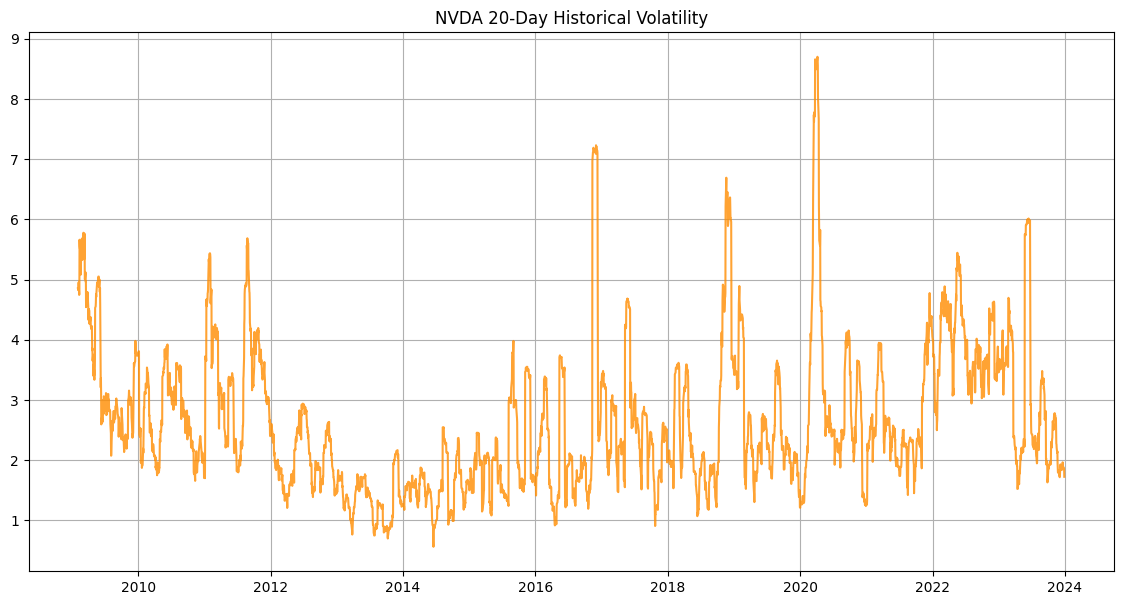

In [64]:
plt.figure(figsize=(14, 7))
plt.plot(nvda_df['Volatility_20_Day'], color='darkorange', alpha=0.8)
plt.title('NVDA 20-Day Historical Volatility')
plt.grid(True)
plt.show()

### Detailed Insights from Financial Visualizations

Analysing the price action through momentum and risk metrics provides a deeper understanding of Nvidia's (NVDA) market dynamics:

1. **NVDA Daily Returns: Performance & Sentiment**
    * **Observation**: The daily returns plot reveals the 'heartbeat' of the stock. Sharp vertical spikes (positive or negative) often correlate with fundamental catalysts such as quarterly earnings beats, product announcements (e.g., new GPU architectures), or macroeconomic shifts affecting the semiconductor sector.
    * **Interpretation**: While frequent fluctuations are normal, consistent 'clustering' of positive returns suggests a strong bullish sentiment. However, large erratic swings indicate that the stock is highly sensitive to news, requiring a higher risk tolerance from investors compared to more stable blue-chip assets.

2. **NVDA 20-Day Historical Volatility: Risk Assessment**
    * **Observation**: Volatility is not constant; it moves in cycles. By tracking the 20-day rolling standard deviation, we can identify periods of 'Volatility Clustering'—where high-volatility days tend to follow high-volatility days.
    * **Interpretation**: When the volatility line peaks, it indicates a period of high uncertainty or rapid price discovery. For a growth-oriented stock like Nvidia, high volatility often precedes significant trend shifts.
    * **Strategic Insight**: Investors can use these insights to adjust position sizing. Lower volatility periods might suggest a consolidating market where the trend is stable, while rising volatility warns of potential 'overheating' or imminent corrections, signaling a time to potentially tighten stop-loss orders or hedge positions.